In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

C:\Softwares\Anaconda\Jupyter\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
X,y=make_moons(n_samples=250,noise=0.05,random_state=42)

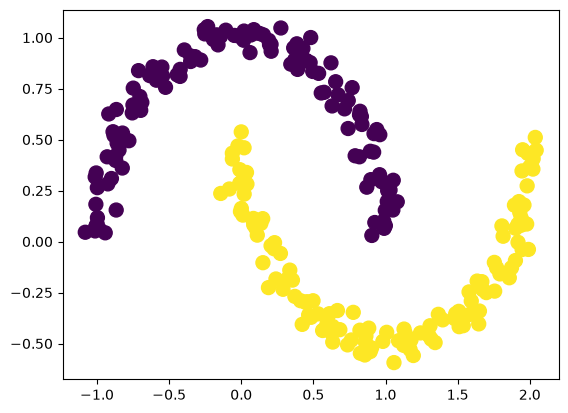

In [3]:
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.show()

In [4]:
model=Sequential()
model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

C:\Softwares\Anaconda\Jupyter\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [6]:
model.get_weights()[0]

array([[-0.69480425,  0.3480193 ,  0.34634727, -0.20849708,  0.6019679 ,
         0.59115106,  0.70546573,  0.20496804,  0.2455492 , -0.4243938 ],
       [-0.04233378,  0.6183192 ,  0.41861552, -0.6480324 ,  0.08075339,
         0.5610326 , -0.33895186, -0.59594715,  0.5545997 , -0.32879868]],
      dtype=float32)

In [7]:
old_weights=model.get_weights()[0]

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [9]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4900 - loss: 0.7026
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4900 - loss: 0.6980
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4900 - loss: 0.6949 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4900 - loss: 0.6924 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4900 - loss: 0.6915
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4900 - loss: 0.6907 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4950 - loss: 0.6901
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6550 - loss: 0.6897
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6350 - loss: 0.6892
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6300 - loss: 0.6887 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6350 - loss: 0.6884 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6400 - l

In [10]:
new_weights=model.get_weights()[0]

In [11]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [12]:
gradient=(old_weights-new_weights)/0.001
percent_change=abs(100*(old_weights-new_weights)/old_weights)

In [13]:
gradient

array([[  437.72748,   683.7664 ,  -498.4612 ,   512.29236,  -467.07742,
         -475.5291 ,  -399.36475,  -526.56616,  -539.8699 ,   522.737  ],
       [-1108.8092 , -1071.1548 ,   961.64215,  -916.16235,  1099.9817 ,
          977.18713,  1074.983  ,   997.19543,   988.9904 , -1065.1168 ]],
      dtype=float32)

In [14]:
percent_change

array([[  63.00012,  196.4737 ,  143.9195 ,  245.70723,   77.59176,
          80.44122,   56.61009,  256.9016 ,  219.86221,  123.17264],
       [2619.2065 ,  173.23654,  229.71968,  141.376  , 1362.1494 ,
         174.17654,  317.1492 ,  167.32953,  178.3251 ,  323.94196]],
      dtype=float32)

In [15]:
old_weights

array([[-0.69480425,  0.3480193 ,  0.34634727, -0.20849708,  0.6019679 ,
         0.59115106,  0.70546573,  0.20496804,  0.2455492 , -0.4243938 ],
       [-0.04233378,  0.6183192 ,  0.41861552, -0.6480324 ,  0.08075339,
         0.5610326 , -0.33895186, -0.59594715,  0.5545997 , -0.32879868]],
      dtype=float32)

In [16]:
new_weights

array([[-1.1325318 , -0.33574712,  0.8448085 , -0.72078943,  1.0690453 ,
         1.0666802 ,  1.1048305 ,  0.73153424,  0.7854191 , -0.9471308 ],
       [ 1.0664754 ,  1.689474  , -0.5430267 ,  0.26812997, -1.0192285 ,
        -0.4161546 , -1.413935  , -1.5931426 , -0.43439078,  0.7363182 ]],
      dtype=float32)

In [17]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
old_weights=model.get_weights()[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, ytest_size=0.20,random_state=42)

In [ ]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 [==============================] - 2s 6ms/step - loss: 0.6932 - accuracy: 0.4900
Epoch 2/100
7/7 [==============================] - 0s 6ms/step - loss: 0.6925 - accuracy: 0.5200
Epoch 3/100
7/7 [==============================] - 0s 4ms/step - loss: 0.6914 - accuracy: 0.6950
Epoch 4/100
7/7 [==============================] - 0s 3ms/step - loss: 0.6897 - accuracy: 0.7950
Epoch 5/100
7/7 [==============================] - 0s 3ms/step - loss: 0.6872 - accuracy: 0.8300
Epoch 6/100
7/7 [==============================] - 0s 4ms/step - loss: 0.6835 - accuracy: 0.8350
Epoch 7/100
7/7 [==============================] - 0s 3ms/step - loss: 0.6788 - accuracy: 0.8550
Epoch 8/100
7/7 [==============================] - 0s 4ms/step - loss: 0.6725 - accuracy: 0.8750
Epoch 9/100
7/7 [==============================] - 0s 5ms/step - loss: 0.6635 - accuracy: 0.8850
Epoch 10/100
7/7 [==============================] - 0s 4ms/step - loss: 0.6516 - accuracy: 0.8900
Epoch 11/100
7/7 [===========

In [ ]:
new_weights = model.get_weights()[0]

In [ ]:
model.optimizer.get_config()["learning_rate"]

0.001

In [ ]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [ ]:
gradient

array([[ 6.685495  , -3.4646986 , -5.3832526 ,  6.741613  , -6.8466363 ,
         5.8019753 , -6.013676  ,  2.311021  ,  0.31654534,  1.327753  ],
       [-5.534008  ,  2.8640625 ,  4.297107  , -6.487876  ,  6.334662  ,
        -5.206227  ,  0.72604764, -4.4065375 , -1.9274204 , -6.5084095 ]],
      dtype=float32)

In [ ]:
percent_change

array([[ 1.1875801 ,  0.61953056,  1.5359294 ,  1.9122909 ,  1.6018827 ,
         1.2191677 ,  5.3679805 ,  0.7799734 ,  0.15018749,  0.25854072],
       [ 5.258102  ,  0.9604039 ,  1.1871884 ,  1.2909728 ,  1.2937336 ,
         0.87578124, 26.933157  , 12.894475  ,  1.8821074 ,  2.2091355 ]],
      dtype=float32)

In [ ]:
old_weights

array([[-0.06470567,  0.38120002,  0.2564506 ,  0.4796242 , -0.41284758,
         0.12111282,  0.3640564 , -0.11997336, -0.7036418 , -0.12918228],
       [ 0.4177161 , -0.646973  ,  0.5538413 ,  0.14968556, -0.1020028 ,
        -0.25845426, -0.1095776 ,  0.22031492, -0.01622504, -0.3014395 ]],
      dtype=float32)

In [ ]:
new_weights

array([[-0.00357266,  0.42682663,  0.36751232,  0.6510883 , -0.47869346,
         0.22171871,  0.4815479 , -0.20610414, -0.73377985, -0.09355866],
       [ 0.4225647 , -0.76475453,  0.56343955,  0.08604728, -0.1019215 ,
        -0.35053518, -0.19012658,  0.28164935,  0.21199906, -0.29813236]],
      dtype=float32)